# Testing PL Switch Experiment Results for Fixed Cations and Varying Mobile Anions
## Overview

The aim of this set of simulation runs is to make the ongoing investigation into switch-based PL a little more realistic by keeping the cation distribution within the device fixed. 

To replicate the idea of a fixed positive ionic species within SIMsalabim, I will dope the device with donor atoms - matching the density I would desire for a mobile species - while setting the mobile cation density to 0. SIMsalabim will not accept 0 ion mobility, so this is the workaround one must take to simulate stationary ionic species. 

For this investigation, I will vary: 
1. The mobility of the mobile anions in the perovskite layer - l2.mu_anion
2. The density of both the mobile anions - l2.N_anion
3. The density of fixed cations - l2.N_D

## Experiment ID: "switch_PL_for_fixed_cations_varying_mobile_anions"
### Set Up

In [1]:
import os, sys
import numpy as np
import typing 
from numbers import Number
import itertools as it
from dataclasses import dataclass
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy.signal import find_peaks
import xarray as xr
try:
    import pySIMsalabim as sim
except ImportError: # add parent directory to sys.path if pySIMsalabim is not installed
    sys.path.append('../..')
    import pySIMsalabim as sim

In [2]:
experiment_id = "switch_PL_for_fixed_cations_varying_mobile_anions"
session_path = os.path.join("../../", "SIMsalabim/ZimT")

In [3]:
# Define fixed parameters that will remain unchanged for each run 
cation_density = 0

# Define varying parameters
anion_mobiliy_values = [1E-14, 5E-14, 1E-15]
ion_densitiy_values = np.geomspace(1.5E21, 1.5E23, 8)

# Here, I want density variations to be independent, and so use the Cartesian product of ion_density_values
parameter_combinations = np.array(list(it.product(ion_densitiy_values, ion_densitiy_values, anion_mobiliy_values)))
fixed_cation_densities = parameter_combinations[:, 0]
mobile_anion_densities = parameter_combinations[:, 1]
anion_mobilities = parameter_combinations[:, 2]

# Pass all experiment parameters to a dictionary
experiment_parameters = {
    "l2.N_cation" : cation_density,
    "l2.mu_anion" : anion_mobilities,
    "l2.N_anion" : mobile_anion_densities,
    "l2.N_D" : fixed_cation_densities
}

output_files = {
    "tjFile" : "tj.dat",
    "varFile" : "varFile.dat"
}

In [4]:
# From the arguments and values, create a parameter .txt file alongside a .sh file containing all the various experiments to run
import uuid 
import hashlib

def get_UUID_from_string(s: str) -> uuid.UUID:
    '''Creates a UUID object based off a passed string'''
    hex_string = hashlib.md5(s.encode("UTF-8")).hexdigest()
    return uuid.UUID(hex=hex_string)

def generate_experiment_files(experiment_parameters: dict[str, float | np.ndarray], session_path: str, experiment_id: str, 
                              tVG_file: str = "tVG.txt", output_files: dict[str, str] = {"tjFile" : "tj.dat"}) -> str:
    '''Generates a bash script where each line corresponds to a specified experiment alongside a .txt file containing all passed parameters'''
    
    # Set up the header of the space seperated parameter file .txt
    parameter_file_string = "UUID "
    for parameter in experiment_parameters.keys(): 
        parameter_file_string += f"{parameter} "
    parameter_file_string = parameter_file_string.strip() + '\n'
    
    # Set up the experiment_zimt_commands file
    zimt_command = "./zimt"
    zimt_commands_file_string = ""
    
    # Set up the tVG command flag and argument
    tVG_file_command_line_argument = f" -tVGFile {tVG_file}"
    
    # Convert the passed experiment parameters to a dataFrame for easy iteration, and parse each row into the relevant files
    experiment_parameters_dataframe = pd.DataFrame(experiment_parameters)
    for _, run in experiment_parameters_dataframe.iterrows():
        run_parameters = ""
        run_command_line_arguments = ""
        
        for parameter, value in run.items():
            run_parameters += f"{value:.2e} "
            run_command_line_arguments += f" -{parameter} {value:.2e}"
        
        run_uuid = str(get_UUID_from_string(run_parameters))
        run_uuid_savefile_tag = f"_{run_uuid}"
        
        for savefile_flag, savefile_name in output_files.items():
            savefile_name_base, savefile_name_extension = os.path.splitext(savefile_name)
            savefile_name = savefile_name_base + f"__{experiment_id}_" + run_uuid_savefile_tag + savefile_name_extension
            
            run_command_line_arguments += f" -{savefile_flag} {savefile_name}"
            
            
        parameter_file_string += run_uuid + " " + run_parameters.strip() + "\n"
        zimt_commands_file_string += zimt_command + tVG_file_command_line_argument + run_command_line_arguments + "\n"
        
    # Save experiment parameters
    parameter_file_name = f"experiment__{experiment_id}__parameters.txt"
    parameter_file_path = os.path.join(session_path, parameter_file_name)
    with open(parameter_file_path, 'w') as file:
        file.write(parameter_file_string)
        
    # Save zimt commands 
    zimt_commands_file_name = f"experiment__{experiment_id}__zimt_commands.sh"
    zimt_commands_file_path = os.path.join(session_path, zimt_commands_file_name)
    with open(zimt_commands_file_path, 'w') as file:
        file.write(zimt_commands_file_string)
        
    return parameter_file_path

In [5]:
parameter_file_path = generate_experiment_files(experiment_parameters, session_path, experiment_id, tVG_file="tVG_high_res.dat", output_files=output_files)

### Experiment Execution
Run the generated experiment bash script commands with 

```~$ parallel :::: experiment__switch_PL_for_fixed_cations_varying_mobile_anions__zimt_commands.sh```

Test the generated experiment bash script commands with 

```~$ parallel --dry-run :::: experiment__switch_PL_for_fixed_cations_varying_mobile_anions__zimt_commands.sh```

## Analysis 
### Reading in and formatting data

In [6]:
# After moving the result run to a directory for safe storage, read in the save path and run parameters
experiment_data_save_directory = f"data_{experiment_id}"
experiment_data_save_path = os.path.join(session_path, experiment_data_save_directory)
experiment_parameter_dataframe = pd.read_csv(parameter_file_path, sep=r'\s+')

In [7]:
import gc
type ExperimentDict = dict[str, float | pd.DataFrame]
    
def zimt_data_to_dataset(save_directory_path: str):
    """Read in run uuid, parameters, and data and store in an list of dictionaries"""

    zimt_runs_transient: list = []
    zimt_runs_Voc_ss: list = []

    # Store each experimental run, including params and tj_data, as a dict and add to zimt_runs
    for _, row in experiment_parameter_dataframe.iterrows():
        zimt_run_uuid = row["UUID"]
        
        
        # Read in the tj_data 
        zimt_run_tj_filename = f"tj__{experiment_id}__{zimt_run_uuid}.dat"
        zimt_run_file_path = os.path.join(save_directory_path, zimt_run_tj_filename)
        zimt_run_tj_data = pd.read_csv(zimt_run_file_path, sep=r'\s+')
        
        # Make sure the run converged for at least some timesteps otherwise delete the df and move on
        if zimt_run_tj_data.empty:
            print('Removing run')
            del zimt_run_tj_data
            continue
        
        # Convert the tj_data to two datasets, one containing the run data, and the other the steady state Voc
        tj_transient_data = zimt_run_tj_data[:-1].set_index('t') # Set the index so from_dataframe reads time as a coordinate
        tj_steady_state_Voc_data = zimt_run_tj_data.set_index('t').tail(1)
        tj_transient_dataset = xr.Dataset.from_dataframe(tj_transient_data)
        tj_steady_state_Voc_dataset = xr.Dataset.from_dataframe(tj_steady_state_Voc_data)
        
        # Read in the var data 
        zimt_run_varFile_filename = f"varFile__{experiment_id}__{zimt_run_uuid}.dat"
        zimt_run_file_path = os.path.join(save_directory_path, zimt_run_varFile_filename)
        zimt_run_varFile_data = pd.read_csv(zimt_run_file_path, sep=r'\s+')
        
        # Conver the var data to two datasets, one containing run data, and the other Voc steady state data
        var_data = zimt_run_varFile_data.set_index(["time", "x"]) # Do this to set time and x as coordinates when read later
        number_of_x_positions = len(var_data.index.levels[1])
        var_transient_data = var_data[:-number_of_x_positions] # Remove the last steady state sim
        var_steady_state_Voc_data = var_data[-number_of_x_positions:]
        var_transient_dataset = xr.Dataset.from_dataframe(var_transient_data)
        var_steady_state_Voc_dataset = xr.Dataset.from_dataframe(var_steady_state_Voc_data)
        
        # Remove the read csv file from memory as everything is now stored in the xarray
        del zimt_run_tj_data
        del zimt_run_varFile_data
        gc.collect()
        
        # Merge the tj and var datasets along the time coordinate
        tj_transient_dataset = tj_transient_dataset.rename({"t": "time"})
        tj_steady_state_Voc_dataset = tj_steady_state_Voc_dataset.rename({"t" : "time"})
        
        run_transient_dataset = xr.merge([tj_transient_dataset, var_transient_dataset], compat='override')
        run_steady_state_Voc_dataset = xr.merge([tj_steady_state_Voc_dataset, var_steady_state_Voc_dataset], compat='override')
        
        # Add the run parameters as extra-dimensions 
        # parameter_dims_and_coords = {
        #     "l2_N_ion" : [row["l2.N_cation"]],
        #     "l2_mu_ion" : [row["l2.mu_cation"]]
        # }
        
        parameter_dims_and_coords = {
            "l2_mu_anion" : [row["l2.mu_anion"]],
            "l2_N_anion" : [row["l2.N_anion"]],
            "l2_N_D" : [row["l2.N_D"]]
        }
        
        # for parameter, value in row.items():
        #     parameter = parameter.replace(".", "_") if "." in parameter else parameter
        #     parameter_dims_and_coords[parameter] = [value]
        
        run_transient_dataset = run_transient_dataset.expand_dims(parameter_dims_and_coords)
        run_steady_state_Voc_dataset = run_steady_state_Voc_dataset.expand_dims(parameter_dims_and_coords)
        # run_transient_dataset.attrs = {"UUID": row["UUID"]}
        
        # Check the run actually converged. If not, do not append it to the array of runs
        if run_transient_dataset.time.size == 0:
            continue
        
        zimt_runs_transient.append(run_transient_dataset)
        zimt_runs_Voc_ss.append(run_steady_state_Voc_dataset)
        
    
    return zimt_runs_transient, zimt_runs_Voc_ss

In [8]:
zimt_xarray_runs, zimt_run_steady_state_Voc_dataset = zimt_data_to_dataset(experiment_data_save_path)
zimt_transient_dataset = xr.combine_by_coords(zimt_xarray_runs)
zimt_Voc_dataset = xr.combine_by_coords(zimt_run_steady_state_Voc_dataset)

/var/folders/0m/gfqnwnj15yb3_ysgltf_03440000gn/T/ipykernel_11069/3285222977.py:2: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  zimt_transient_dataset = xr.combine_by_coords(zimt_xarray_runs)
/var/folders/0m/gfqnwnj15yb3_ysgltf_03440000gn/T/ipykernel_11069/3285222977.py:2: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  zimt_transient_dataset = xr.combine_by_c

In [12]:
zimt_transient_dataset

<xarray.Dataset> Size: 1GB
Dimensions:        (l2_mu_anion: 3, l2_N_anion: 8, l2_N_D: 8, time: 102, x: 252)
Coordinates:
  * l2_mu_anion    (l2_mu_anion) float64 24B 1e-15 1e-14 5e-14
  * l2_N_anion     (l2_N_anion) float64 64B 1.5e+21 2.9e+21 ... 7.77e+22 1.5e+23
  * l2_N_D         (l2_N_D) float64 64B 1.5e+21 2.9e+21 ... 7.77e+22 1.5e+23
  * time           (time) float64 816B 0.0 0.1 0.2 ... 8.037e+03 8.965e+03 1e+04
  * x              (x) float64 2kB 0.0 1.273e-10 ... 5.332e-07 5.348e-07
Data variables: (12/57)
    Vext           (l2_mu_anion, l2_N_anion, l2_N_D, time) float64 157kB 0.0 ...
    Jext           (l2_mu_anion, l2_N_anion, l2_N_D, time) float64 157kB -217...
    errJ           (l2_mu_anion, l2_N_anion, l2_N_D, time) float64 157kB 3.88...
    Vint           (l2_mu_anion, l2_N_anion, l2_N_D, time) float64 157kB 0.0 ...
    Jint           (l2_mu_anion, l2_N_anion, l2_N_D, time) float64 157kB -217...
    G_frac         (l2_mu_anion, l2_N_anion, l2_N_D, time) float64 157kB 1.0 ...
    ...             ...
    BulkSRHp       (l2_mu_anion, l2_N_anion, l2_N_D, time, x) float64 39MB 0....
    IntSRHn        (l2_mu_anion, l2_N_anion, l2_N_D, time, x) float64 39MB 0....
    IntSRHp        (l2_mu_anion, l2_N_anion, l2_N_D, time, x) float64 39MB 0....
    Jn             (l2_mu_anion, l2_N_anion, l2_N_D, time, x) float64 39MB -2...
    Jp             (l2_mu_anion, l2_N_anion, l2_N_D, time, x) float64 39MB 2....
    lid            (l2_mu_anion, l2_N_anion, l2_N_D, time, x) float64 39MB 1....

### Check Ion Distributions

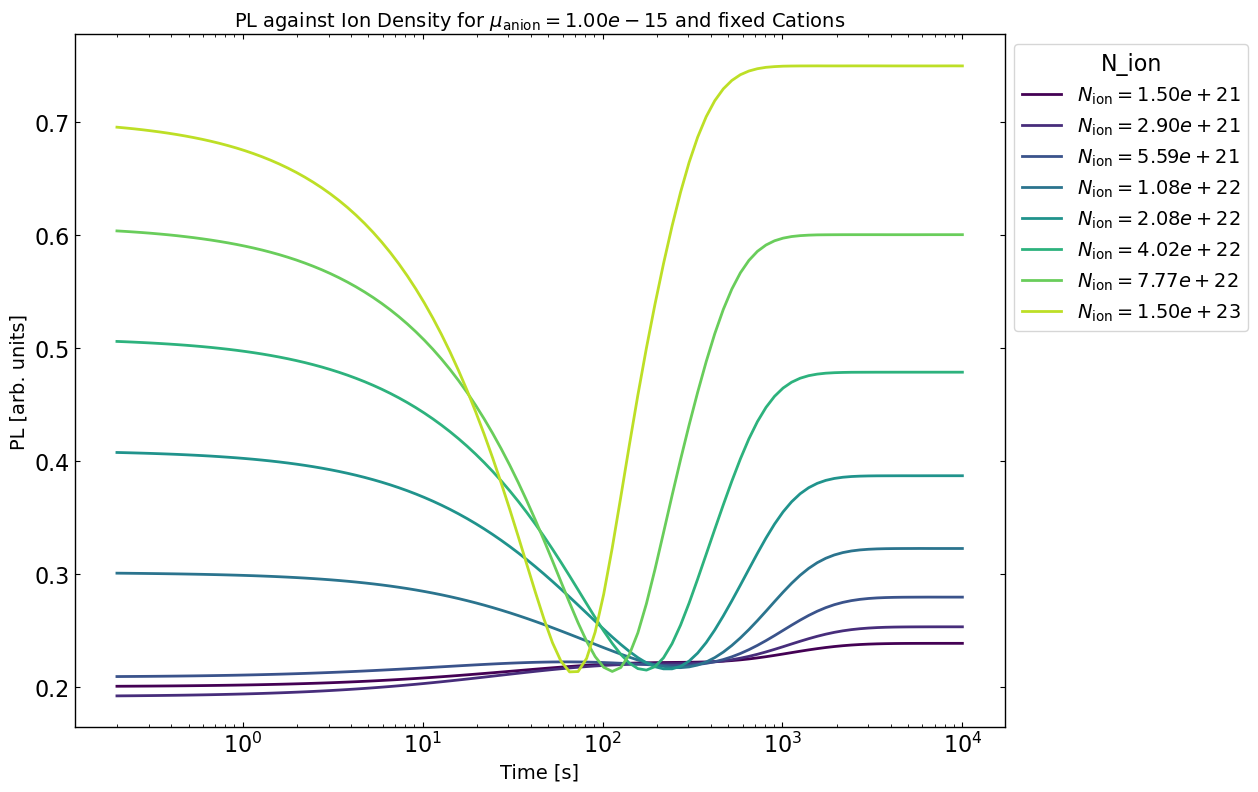

In [9]:
from cycler import cycler 
import matplotlib
import matplotlib.pyplot as plt

# Prep dataset for plotting
fixed_ion_mobility = 1E-15
fixed_mobility_data = zimt_transient_dataset.rename({'JdirL2': 'PL'}).PL.where(zimt_transient_dataset.time >= 0.2, drop=True)
fixed_mobility_data = fixed_mobility_data.where(fixed_mobility_data.l2_N_D == fixed_mobility_data.l2_N_anion, drop=True).sel(l2_mu_anion=fixed_ion_mobility)

fig = plt.figure(figsize=(12,9))
ax = fig.add_subplot()

# Define graph colours and a colour cycler
color_map = matplotlib.colormaps.get_cmap('viridis')
colors = color_map(np.linspace(0, 0.9, len(fixed_mobility_data.l2_N_D)))

# Set a cycler to change the color of each subsequent line according to viridis
custom_cycler = cycler(color=colors)
ax.set_prop_cycle(custom_cycler)

labels = []

# Plot lines
for index, density in enumerate(fixed_mobility_data.l2_N_anion.values):
    fixed_mobility_data.isel(l2_N_anion=index, l2_N_D=index).plot.line(x='time', hue="l2_N_anion", xscale='log', add_legend=False, ax=ax)
    labels.append(f"$N_\\text{{ion}}={density:.2e}$")

    
ax.legend(labels, title="N_ion", bbox_to_anchor=(1,1))
ax.set_xlabel("Time [s]")
ax.set_ylabel("PL [arb. units]")
ax.set_title(f"PL against Ion Density for $\\mu_\\text{{anion}} = {fixed_mobility_data.l2_mu_anion.item():.2e}$ and fixed Cations")
plt.savefig("PL response for varying mobile anion and fixed cation density.pdf", format='pdf', bbox_inches='tight')
plt.show()

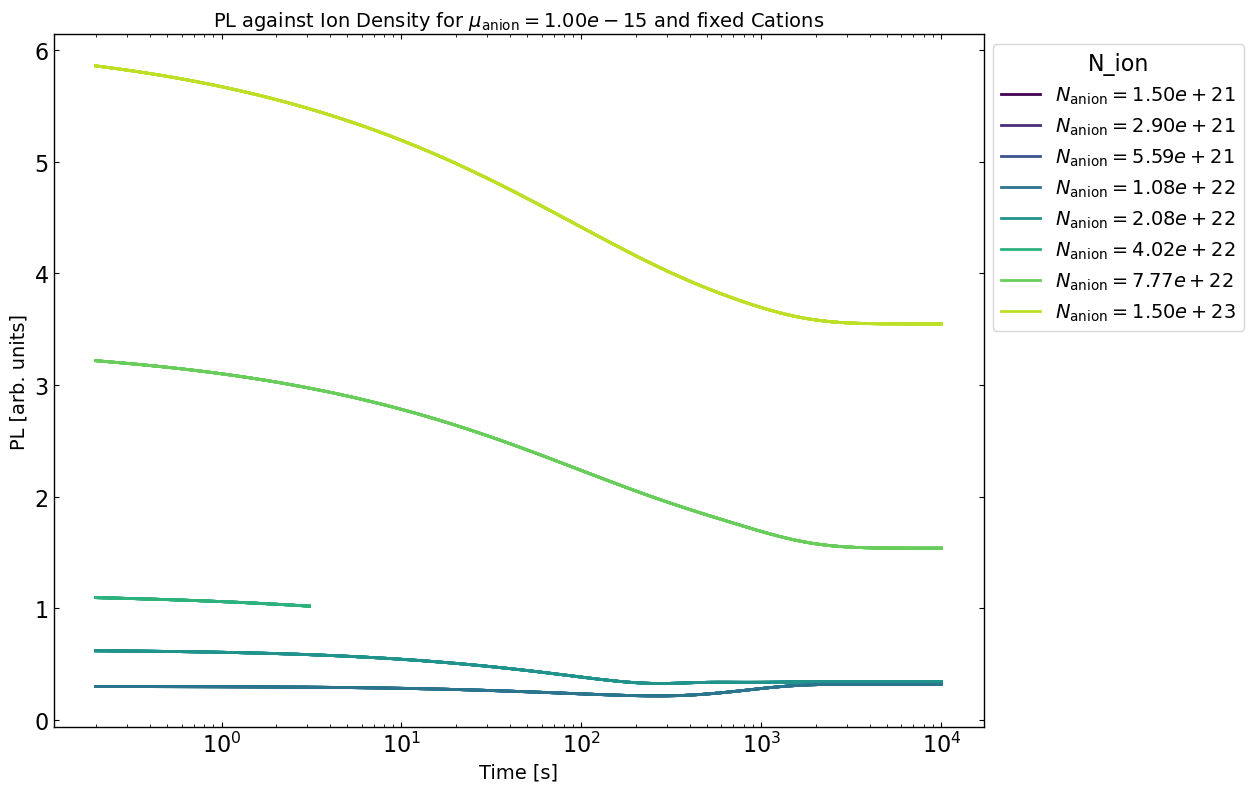

In [10]:
from cycler import cycler 
import matplotlib
import matplotlib.pyplot as plt

# Prep dataset for plotting
fixed_ion_mobility = 1E-15
fixed_mobility_data = zimt_transient_dataset.rename({'JdirL2': 'PL'}).PL.where(zimt_transient_dataset.time >= 0.2, drop=True)
fixed_mobility_data = fixed_mobility_data.sel(l2_mu_anion=fixed_ion_mobility, l2_N_D=1E22, method='nearest')

fig = plt.figure(figsize=(12,9))
ax = fig.add_subplot()

# Define graph colours and a colour cycler
color_map = matplotlib.colormaps.get_cmap('viridis')
colors = color_map(np.linspace(0, 0.9, len(fixed_mobility_data.l2_N_anion)))

# Set a cycler to change the color of each subsequent line according to viridis
custom_cycler = cycler(color=colors)
ax.set_prop_cycle(custom_cycler)

labels = []

# Plot lines
for index, density in enumerate(fixed_mobility_data.l2_N_anion.values):
    fixed_mobility_data.plot.line(x='time', hue="l2_N_anion", xscale='log', add_legend=False, ax=ax)
    labels.append(f"$N_\\text{{anion}}={density:.2e}$")

    
ax.legend(labels, title="N_ion", bbox_to_anchor=(1,1))
ax.set_xlabel("Time [s]")
ax.set_ylabel("PL [arb. units]")
ax.set_title(f"PL against Ion Density for $\\mu_\\text{{anion}} = {fixed_mobility_data.l2_mu_anion.item():.2e}$ and fixed Cations")
plt.show()

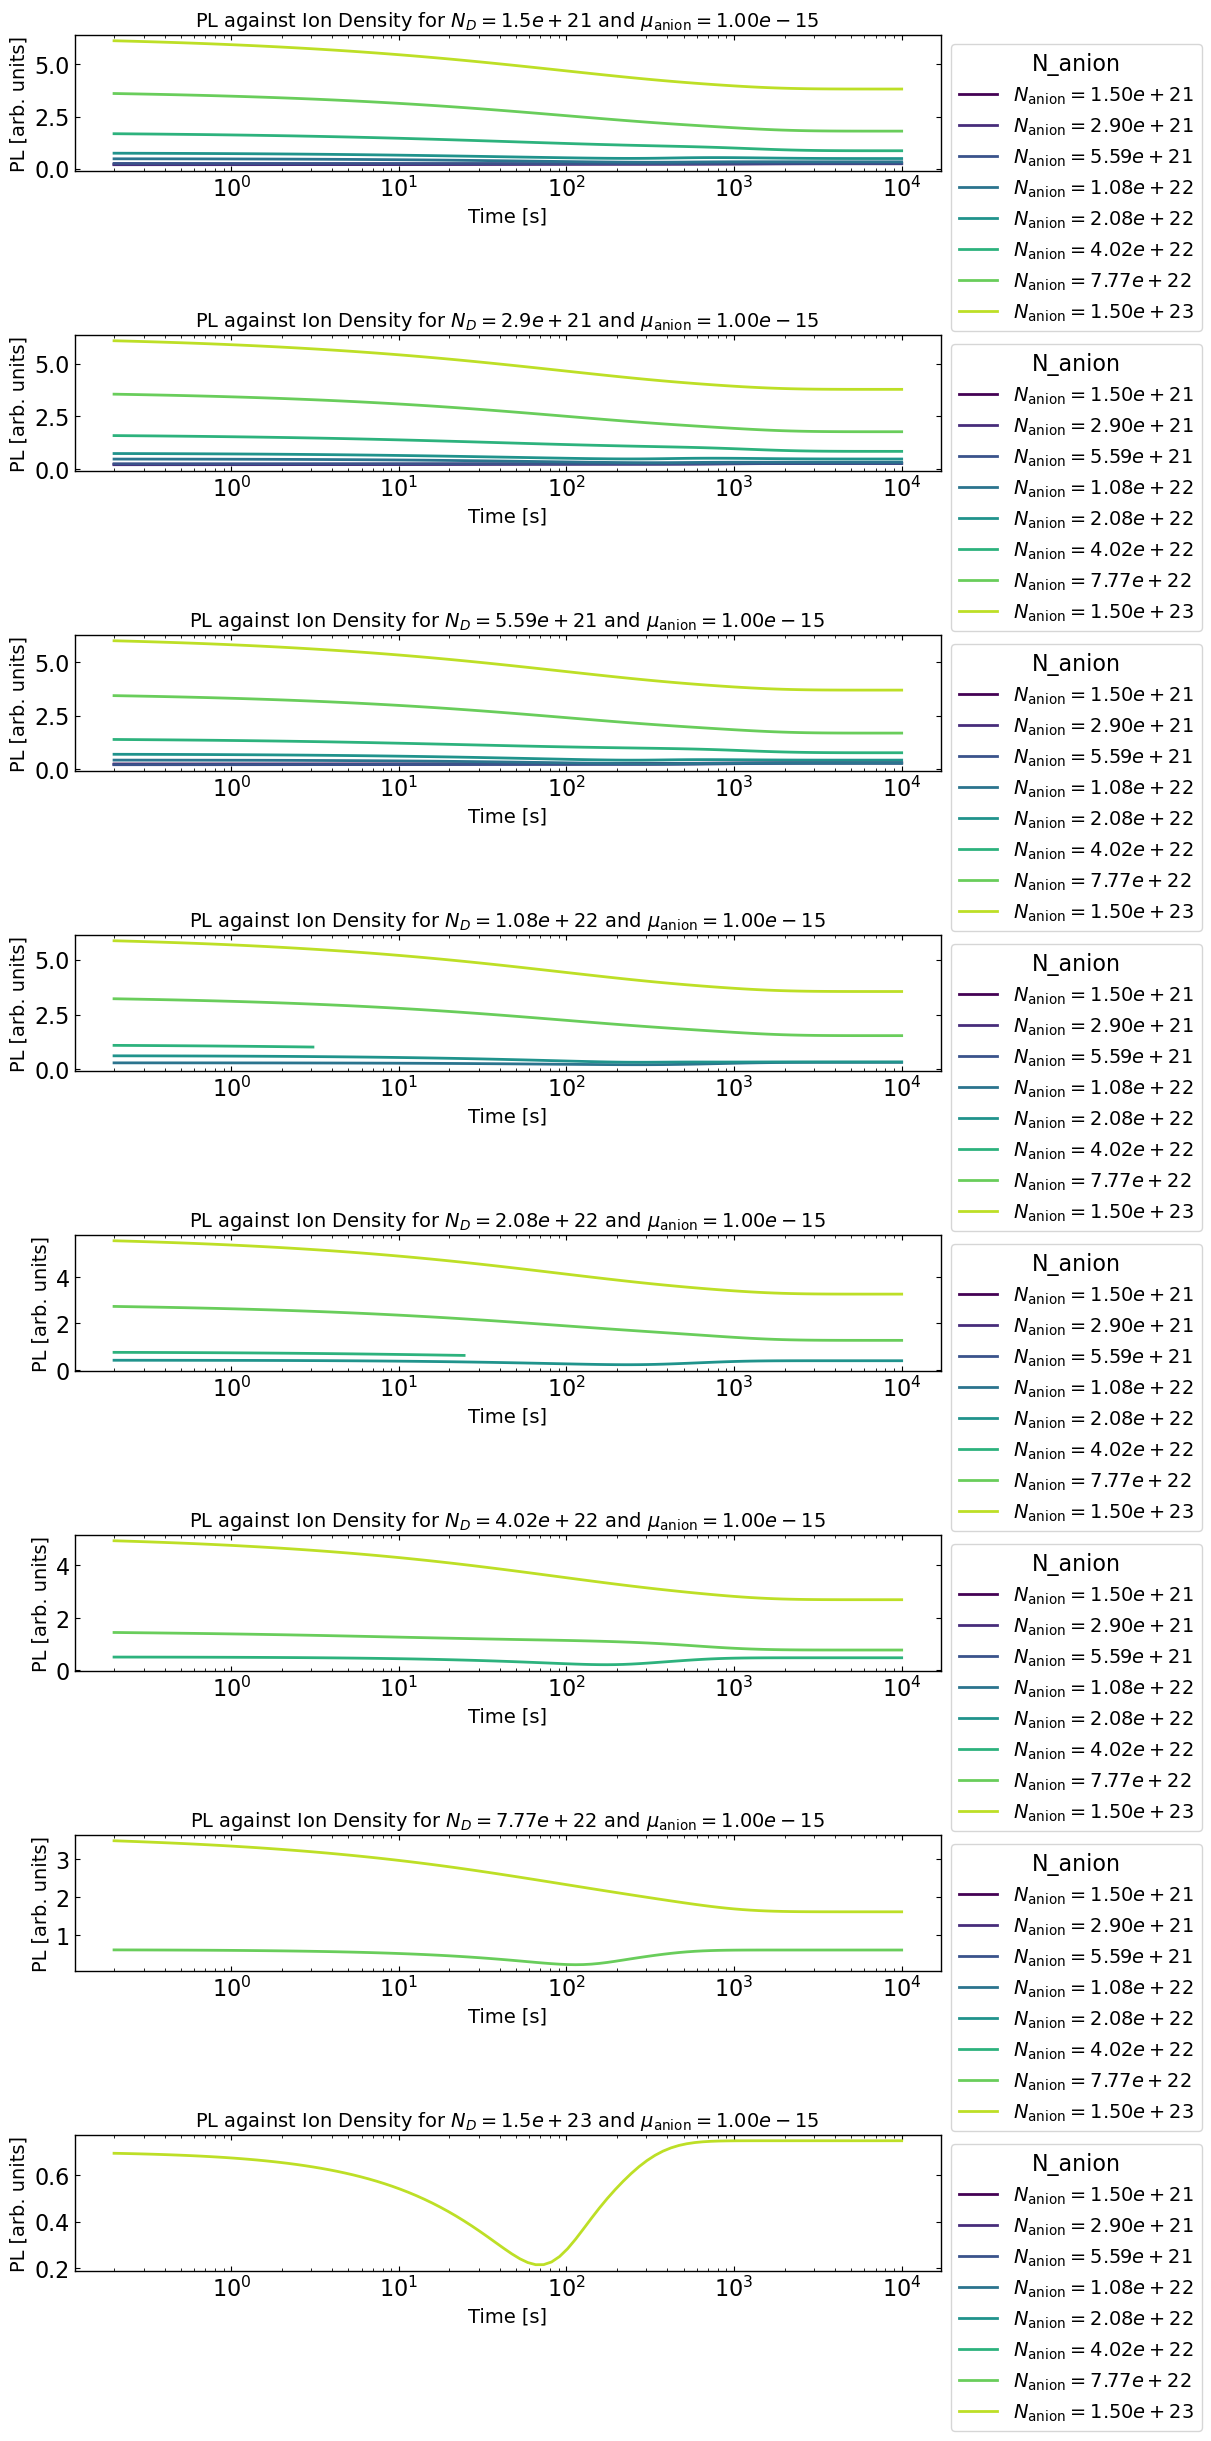

In [11]:
# Prep dataset for plotting
fixed_ion_mobility = 1e-15
fixed_cation_density = 1E22
fixed_mobility_data = zimt_transient_dataset.rename({'JdirL2': 'PL'}).PL.where(zimt_transient_dataset.time >= 0.2, drop=True).sel(l2_mu_anion=fixed_ion_mobility)

# Get the number of different fixed ion densities
number_of_fixed_ion_densities = fixed_mobility_data.l2_N_D.values.size

fig, axes = plt.subplots(number_of_fixed_ion_densities, 1, figsize=(12,number_of_fixed_ion_densities*3), layout='constrained')

# Define graph colours and a colour cycler
color_map = matplotlib.colormaps.get_cmap('viridis')
colors = color_map(np.linspace(0, 0.9, fixed_mobility_data.l2_N_anion.size))

# Set a cycler to change the color of each subsequent line according to viridis
custom_cycler = cycler(color=colors)
ax.set_prop_cycle(custom_cycler)

# Plot lines
for index, fixed_cation_density in enumerate(fixed_mobility_data.l2_N_D.values):
    axes[index].set_prop_cycle(custom_cycler)
    fixed_mobility_and_density_data = fixed_mobility_data.sel(l2_N_D=fixed_cation_density, method='nearest')
    fixed_mobility_and_density_data.plot.line(x='time', hue="l2_N_anion", xscale='log', add_legend=False, ax=axes[index])
    axes[index].legend(labels, title="N_anion", bbox_to_anchor=(1,1))
    axes[index].set_xlabel("Time [s]")
    axes[index].set_ylabel("PL [arb. units]")
    axes[index].set_title(f"PL against Ion Density for $N_D={fixed_mobility_and_density_data.l2_N_D.item()}$ and $\\mu_\\text{{anion}} = {fixed_ion_mobility:.2e}$ ")
plt.show()